# 🧬 Algoritmo Genético — Maximizar Función

**Objetivo:** Maximizar la función **f(x) = x · sin(10 π x) + 1**

- **Dominio:** x ∈ [0, 1]

## Instalación de dependencias

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

## Función objetivo y Parámetros del algoritmo
Modifica aquí los valores antes de ejecutar.

In [18]:
# FUNCIÓN OBJETIVO
def f(x):
    return x * np.sin(10 * np.pi * x) + 1

# PARÁMETROS DEL ALGORITMO GENÉTICO
TAM_POBLACION  = 50      # Individuos por generación
N_GENERACIONES = 100     # numero de generaciones
PROB_CRUCE     = 0.8     # probabilidad de cruce
PROB_MUTACION  = 0.1     # probabilidad de mutación
ELITISMO       = 2       # mejores individuos que pasan directamente

np.random.seed(42)

## Funciones del algoritmo genético

In [19]:
# Iniciar población
def inicializar(n):
    """Población inicial aleatoria en [0, 1]"""
    return np.random.uniform(0, 1, n)

# Selección del mejor cromosoma
def seleccion(poblacion, aptitudes):
    """Selección por torneo (tamaño 3)"""
    seleccionados = []
    for _ in range(len(poblacion)):
        idx = np.random.choice(len(poblacion), 3, replace=False)
        ganador = idx[np.argmax(aptitudes[idx])]
        seleccionados.append(poblacion[ganador])
    return np.array(seleccionados)


# Cruce de cromosomas
def cruce(padre1, padre2, prob):
    """Cruce aritmético (promedio ponderado)"""
    if np.random.rand() < prob:
        alpha = np.random.rand()
        hijo1 = alpha * padre1 + (1 - alpha) * padre2
        hijo2 = alpha * padre2 + (1 - alpha) * padre1
        return hijo1, hijo2
    return padre1, padre2

# Mutación
def mutar(individuo, prob):
    """Mutación gaussiana pequeña"""
    if np.random.rand() < prob:
        individuo += np.random.normal(0, 0.05)
        individuo = np.clip(individuo, 0, 1)   # mantener en [0, 1]
    return individuo

## Ejecutar algoritmo genético

In [20]:
poblacion = inicializar(TAM_POBLACION)

historial_mejor   = []   # mejor valor por generación
historial_promedio = []   # valor promedio por generación
historial_x_mejor = []   # x del mejor individuo
snapshots = []          # poblaciones para animación

for gen in range(N_GENERACIONES):
    aptitudes = f(poblacion)

    # Guardar estadísticas
    idx_mejor = np.argmax(aptitudes)
    historial_mejor.append(aptitudes[idx_mejor])
    historial_promedio.append(aptitudes.mean())
    historial_x_mejor.append(poblacion[idx_mejor])
    snapshots.append(poblacion.copy())

    # Elites: conservar los mejores
    elite_idx = np.argsort(aptitudes)[-ELITISMO:]
    elite = poblacion[elite_idx].copy()

    # Selección y reproducción
    padres = seleccion(poblacion, aptitudes)
    nueva_poblacion = list(elite)
    #Mutar
    for i in range(0, TAM_POBLACION - ELITISMO, 2):
        h1, h2 = cruce(padres[i], padres[i + 1], PROB_CRUCE)
        nueva_poblacion.append(mutar(h1, PROB_MUTACION))
        if len(nueva_poblacion) < TAM_POBLACION:
            nueva_poblacion.append(mutar(h2, PROB_MUTACION))

    poblacion = np.array(nueva_poblacion[:TAM_POBLACION])

# Resultado final
aptitudes_finales = f(poblacion)
mejor_x   = poblacion[np.argmax(aptitudes_finales)]
mejor_val = aptitudes_finales.max()

print("=" * 40)
print(f"  Mejor x   : {mejor_x:.6f}")
print(f"  f(x) máx  : {mejor_val:.6f}")
print("=" * 40)

  Mejor x   : 0.851190
  f(x) máx  : 1.850595


## Visualización

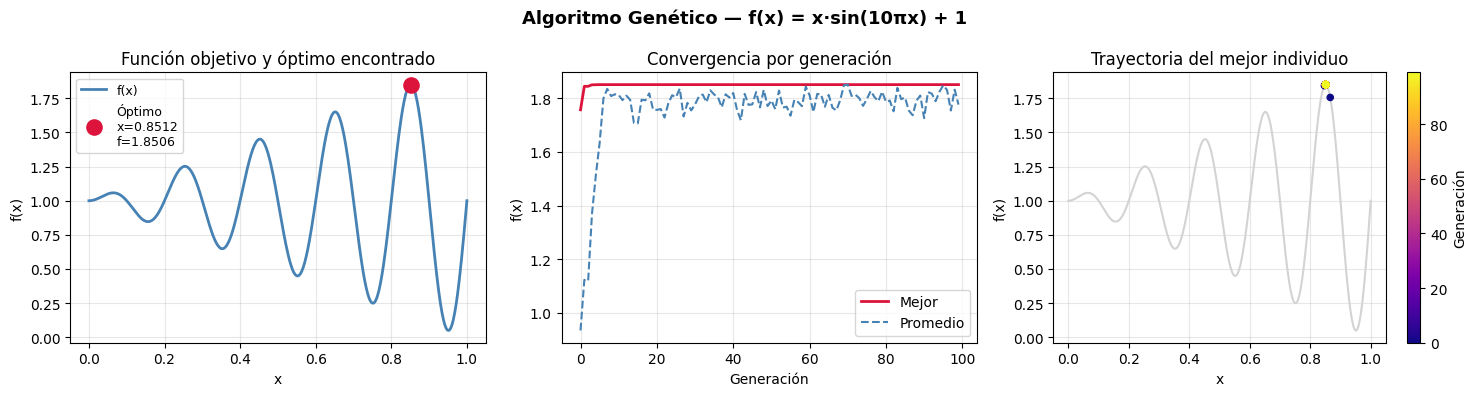

In [21]:
x_plot = np.linspace(0, 1, 500)
y_plot = f(x_plot)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Algoritmo Genético — f(x) = x·sin(10πx) + 1", fontsize=13, fontweight='bold')

# --- Gráfica 1: Función y mejor solución ---
ax1 = axes[0]
ax1.plot(x_plot, y_plot, 'steelblue', lw=2, label='f(x)')
ax1.scatter(mejor_x, mejor_val, color='crimson', s=120, zorder=5,
            label=f'Óptimo\nx={mejor_x:.4f}\nf={mejor_val:.4f}')
ax1.set_xlabel('x')
ax1.set_ylabel('f(x)')
ax1.set_title('Función objetivo y óptimo encontrado')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# --- Gráfica 2: Convergencia del mejor y promedio ---
ax2 = axes[1]
ax2.plot(historial_mejor,    color='crimson',    lw=2, label='Mejor')
ax2.plot(historial_promedio, color='steelblue',  lw=1.5, ls='--', label='Promedio')
ax2.set_xlabel('Generación')
ax2.set_ylabel('f(x)')
ax2.set_title('Convergencia por generación')
ax2.legend()
ax2.grid(alpha=0.3)

# --- Gráfica 3: Trayectoria del mejor individuo ---
ax3 = axes[2]
ax3.plot(x_plot, y_plot, 'lightgray', lw=1.5)
sc = ax3.scatter(historial_x_mejor, historial_mejor,
                  c=range(N_GENERACIONES), cmap='plasma', s=20, zorder=3)
plt.colorbar(sc, ax=ax3, label='Generación')
ax3.set_xlabel('x')
ax3.set_ylabel('f(x)')
ax3.set_title('Trayectoria del mejor individuo')
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Animación

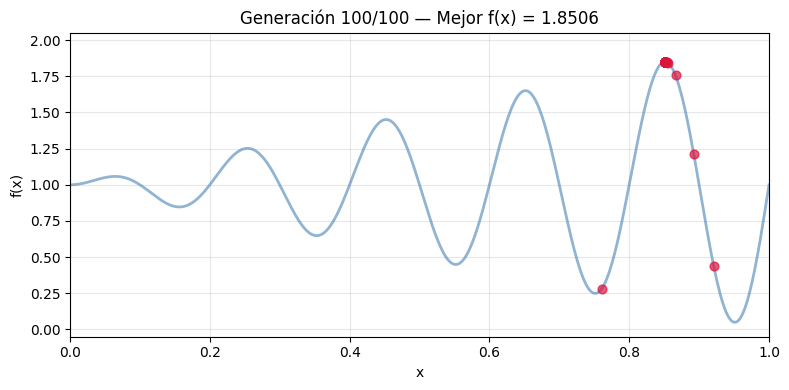

In [22]:
fig_anim, ax_anim = plt.subplots(figsize=(8, 4))
ax_anim.plot(x_plot, y_plot, 'steelblue', lw=2, alpha=0.6)
puntos = ax_anim.scatter([], [], color='crimson', s=40, zorder=5, alpha=0.7)
titulo = ax_anim.set_title('')
ax_anim.set_xlim(0, 1)
ax_anim.set_ylim(y_plot.min() - 0.1, y_plot.max() + 0.2)
ax_anim.set_xlabel('x')
ax_anim.set_ylabel('f(x)')
ax_anim.grid(alpha=0.3)

def actualizar(frame):
    pop = snapshots[frame]
    puntos.set_offsets(np.c_[pop, f(pop)])
    titulo.set_text(f'Generación {frame + 1}/{N_GENERACIONES} — Mejor f(x) = {historial_mejor[frame]:.4f}')
    return puntos, titulo

anim = animation.FuncAnimation(fig_anim, actualizar,
                                frames=N_GENERACIONES, interval=80, blit=True)
plt.tight_layout()
HTML(anim.to_jshtml())

## Análisis de Resultados

El algoritmo genético ha logrado encontrar un valor `x` de `0.851190` que maximiza la función `f(x)` a `1.850595`.

Estos resultados indican que el algoritmo ha convergido exitosamente hacia una solución cercana al óptimo global de la función. Las gráficas de convergencia y trayectoria del mejor individuo (`Visualización`) deberían confirmar la estabilidad y eficiencia de la búsqueda a lo largo de las generaciones.